In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import great_expectations as gx


In [3]:
dataset = load_dataset("ag_news")


Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Pc\.cache\huggingface\datasets\ag_news\default\0.0.0\eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sat Jan 24 21:09:11 2026).


In [4]:
sampled = dataset["train"].shuffle(seed=42).select(range(10_000))
df = pd.DataFrame(sampled)


In [5]:
df.head()
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10000 non-null  object
 1   label   10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


,text,label
count,10000,10000.000000
unique,10000,NaN
top,Bangladesh paralysed by strikes Opposition act...,NaN
freq,1,NaN
mean,NaN,1.494700
std,NaN,1.123876
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,3.000000


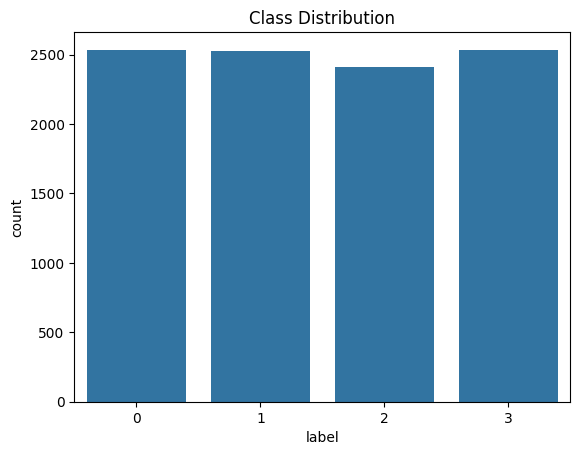

In [6]:
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.show()


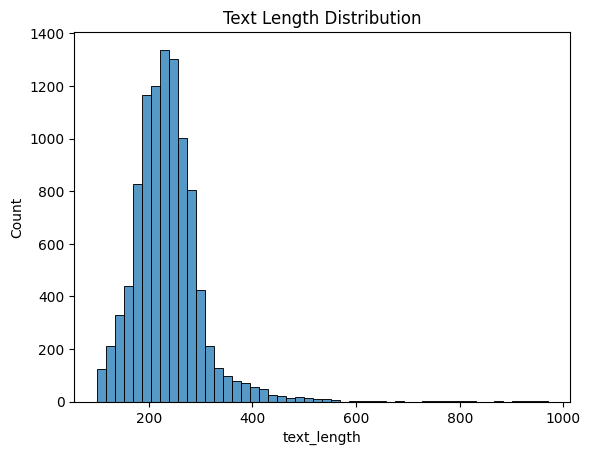

In [7]:
df["text_length"] = df["text"].apply(len)

sns.histplot(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()


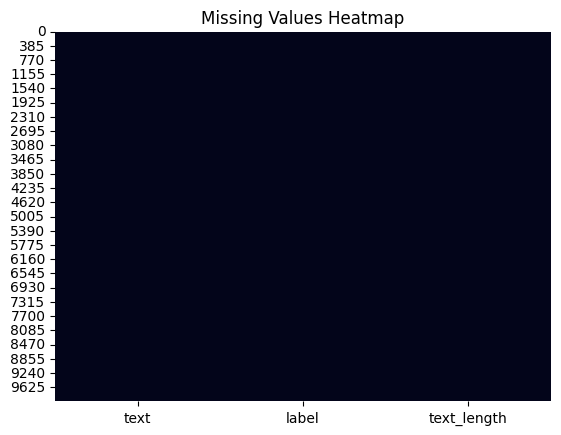

In [8]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [9]:
context = gx.get_context()


In [21]:
import great_expectations as gx

# Convert dataframe to GX dataset
ge_df = gx.from_pandas(df)

# Add expectations
ge_df.expect_column_values_to_not_be_null("text")
ge_df.expect_column_values_to_not_be_null("label")
ge_df.expect_column_values_to_be_between("label", 0, 3)
ge_df.expect_table_row_count_to_be_between(1, 200000)

# Validate
results = ge_df.validate()
print(results)

AttributeError: module 'great_expectations' has no attribute 'from_pandas'

In [14]:
ge_df.expect_column_values_to_not_be_null("text")
ge_df.expect_column_values_to_not_be_null("label")
ge_df.expect_column_values_to_be_between("label", 0, 3)

# optional extra checks
ge_df.expect_table_row_count_to_be_between(1, 200000)
ge_df.expect_column_values_to_be_unique("text", mostly=0.95)

results = ge_df.validate()
results



NameError: name 'ge_df' is not defined

In [ ]:
results = validator.validate()
results


In [11]:
import great_expectations as ge
print(ge.__version__)


1.1.0
